In [42]:
!pip install python-louvain

from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/AM


In [35]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [36]:
G_directed = nx.DiGraph()
G_directed.add_nodes_from(visited)
G_directed.add_edges_from(sample_edges)
G = G_directed.to_undirected()

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 1303


The above code samples nodes using BFS from a directed graph because we want something to analyze, and if we took random nodes the chance of nodes being connected is low.

Modularity: 0.5587


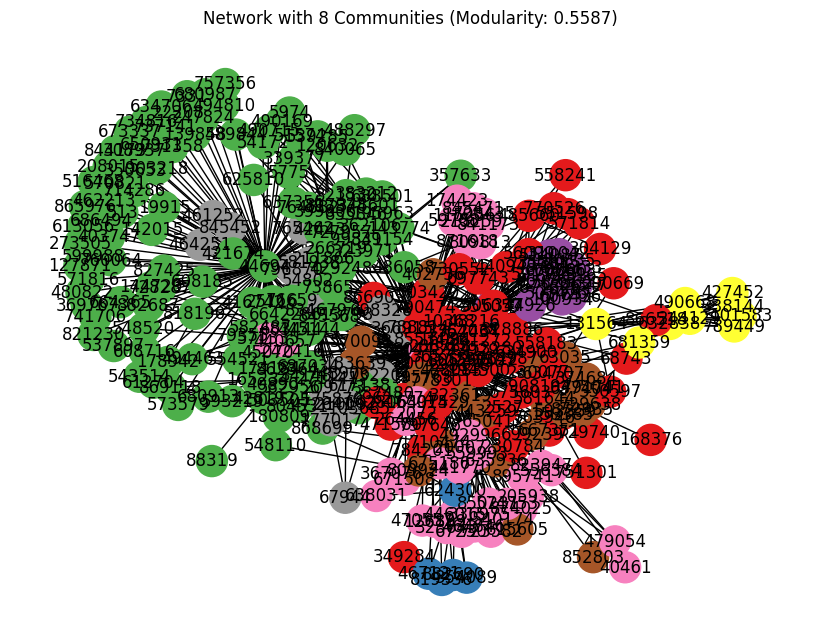

In [38]:
communities = community_louvain.best_partition(G)

modularity = community_louvain.modularity(communities, G)
print(f"Modularity: {modularity:.4f}")

colors = [communities[node] for node in G.nodes()]
num_communities = len(set(communities.values()))
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, cmap=plt.cm.Set1,
        with_labels=True, node_size=500)
plt.title(f"Network with {num_communities} Communities (Modularity: {modularity:.4f})")
plt.show()

The Louvain method singles out 8 communities with a relatively high modularity score meaning edges connecting different communities are rarer which makes sense considering these are hyperlinks.

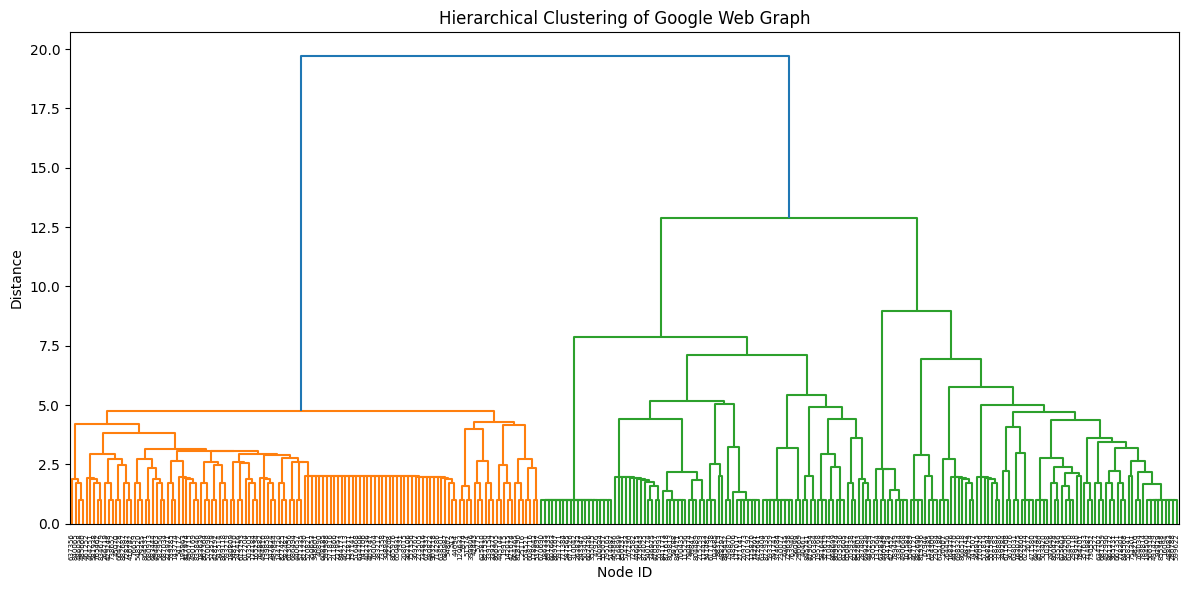

In [50]:
path_length = dict(nx.all_pairs_shortest_path_length(G))
distances = np.zeros((len(G), len(G)))
for i, u in enumerate(G.nodes()):
  for j, v in enumerate(G.nodes()):
    distances[i, j] = path_length[u][v]

condensed_dist = squareform(distances)

Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=list(G.nodes()), leaf_rotation=90)
plt.title('Hierarchical Clustering of Google Web Graph')
plt.xlabel('Node ID')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Found 113 potential hierarchical bridge nodes.
First 10 hierarchical bridge nodes: [304129, 99841, 818190, 45070, 54802, 765462, 554521, 25116, 323619, 638501]


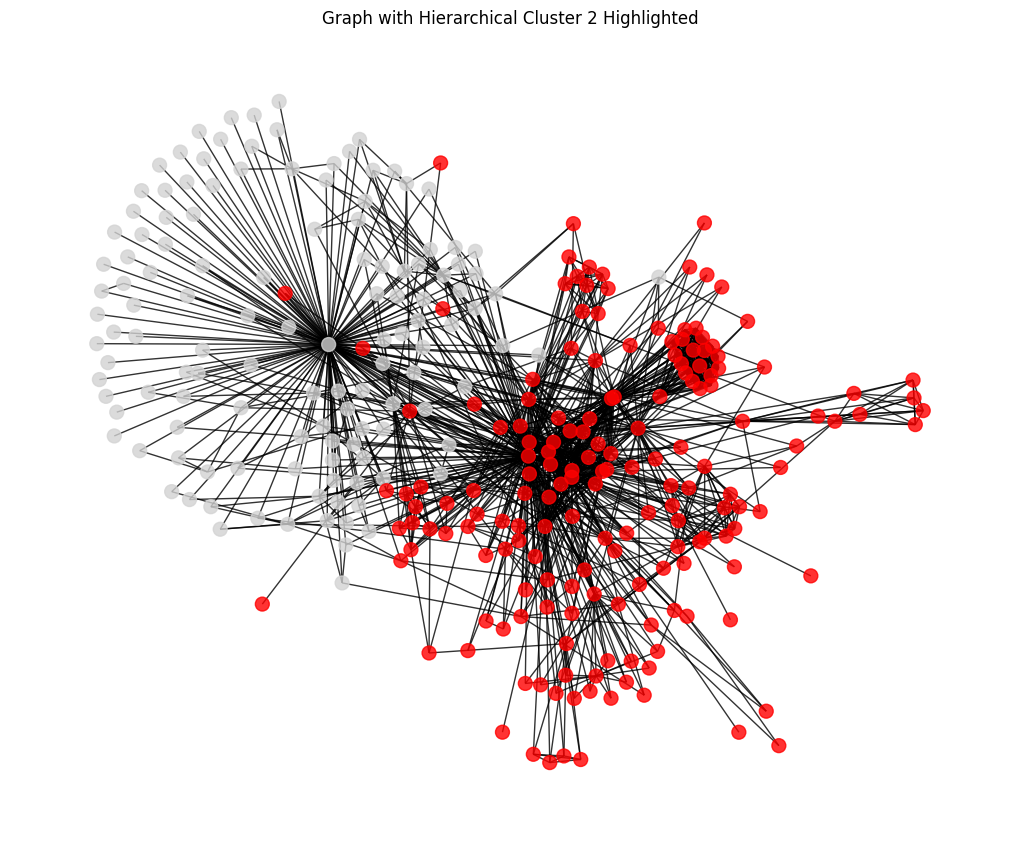

In [52]:
clusters = fcluster(Z, 2, criterion='maxclust')

node_to_cluster_map = {node: clusters[i] for i, node in enumerate(G.nodes())}

hierarchical_bridge_nodes = set()
for u, v in G.edges():
  cluster_u = node_to_cluster_map.get(u)
  cluster_v = node_to_cluster_map.get(v)

  if cluster_u is not None and cluster_v is not None and cluster_u != cluster_v:
    hierarchical_bridge_nodes.add(u)
    hierarchical_bridge_nodes.add(v)

print(f"Found {len(hierarchical_bridge_nodes)} potential hierarchical bridge nodes.")
print(f"First 10 hierarchical bridge nodes: {list(hierarchical_bridge_nodes)[:10]}")

target_hierarchical_cluster_id = clusters[0]

node_colors_hierarchical_highlight = []
for node in G.nodes():
  if node_to_cluster_map.get(node) == target_hierarchical_cluster_id:
    node_colors_hierarchical_highlight.append('red')
  else:
    node_colors_hierarchical_highlight.append('lightgray')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=node_colors_hierarchical_highlight,
        with_labels=False, node_size=100, alpha=0.8)
plt.title(f"Graph with Hierarchical Cluster {target_hierarchical_cluster_id} Highlighted")
plt.axis('off')
plt.show()

In [48]:
num_hierarchical_communities = len(np.unique(clusters))
print(f"Number of communities found with hierarchical clustering: {num_hierarchical_communities}")

Number of communities found with hierarchical clustering: 2


The dendogram and clustering present a much lower community count than when using the Louvaine method. This is further solidified by the fact so many theoretical bridges (links) between communities (pages) are found.